[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Merced-College/cpsc09-ai-data-workshops/blob/main/projectBasedLearningModule1/arduino_motion_lab.ipynb)

## ⚠️ Before You Begin
- You will use an **Arduino Nano 33 BLE Sense** (or Nano 33 BLE Sense Rev2) and the **Arduino IDE**.
- You will copy data output from the Arduino 33 BLE Sense, from the **Serial Monitor** and paste it into this Colab.
- This notebook is written to match the UC Berkeley **Data 8** workflow: **tables → visualizations → functions on tables**.

**What you will submit** is listed at the end.


<div style="text-align:center;">
<img src="https://raw.githubusercontent.com/Merced-College/cpsc09-ai-data-workshops/main/img/decorativeimage3.png"
alt="Decorative banner illustrating Arduino sensor data collection and data science analysis, with graphs, a laptop, and a quote about identifying categories and comparing groups from the Data 8 textbook."
width="900">
</div>

# PBL 2: Arduino Nano 33 BLE Sense — Motion Data to Data Science
*Merced College Data Science Workshops (aligned with Data 8 Ch. 6–8)*  
*Last updated: 2026-03-04*


## Big Picture (Data 8 Chapters 6–8)
In Data 8, you learn that:
- A **table** is a way to organize observations (rows) and variables (columns).
- **Visualizations** help you spot patterns and compare groups.
- **Functions** let you compute new columns and summary statistics from tables.

In this lab, your Arduino becomes a **data collection device**. Your motion sensor readings become a **dataset**.

### Your dataset will look like this
| motion | t | ax | ay | az |
|---|---:|---:|---:|---:|
| still | 0.00 | 0.01 | 0.98 | 0.02 |
| still | 0.05 | 0.02 | 0.97 | 0.01 |
| shake | 0.00 | 0.72 | -0.39 | 0.58 |

Where **motion** is the *category* (like “ice cream flavor” in the textbook), and **ax/ay/az** are numerical variables.


<h2>Arduino Nano 33 BLE Sense</h2>

<p>
The <strong>Arduino Nano 33 BLE Sense</strong> is a small microcontroller board designed for projects involving
<strong>sensor data collection</strong>, <strong>machine learning</strong>, and <strong>IoT applications</strong>.
It includes built-in sensors that allow us to collect real-world data such as motion, sound, temperature, light, and humidity.
</p>

<p>
In this workshop, we will use the <strong>accelerometer</strong> and <strong>gyroscope</strong> to collect motion data and analyze it
using data science tools in Python.
</p>

<h3>Learn more (official Arduino resources)</h3>
<ul>
  <li>
    <a href="https://docs.arduino.cc/hardware/nano-33-ble-sense-rev2/" target="_blank" rel="noopener">
      Arduino Nano 33 BLE Sense documentation
    </a>
  </li>
  <li>
    <a href="https://docs.arduino.cc/tutorials/nano-33-ble-sense-rev2/cheat-sheet/" target="_blank" rel="noopener">
      Arduino Nano 33 BLE Sense cheat sheet
    </a>
  </li>
  <li>
    <a href="https://docs.arduino.cc/resources/pinouts/ABX00069-full-pinout.pdf" target="_blank" rel="noopener">
      Arduino Nano 33 BLE Sense pinout (PDF)
    </a>
  </li>
</ul>

<hr>

<h3>Arduino Nano 33 BLE Sense Board</h3>

<p>The image below shows the Arduino Nano 33 BLE Sense board.</p>

<img src="https://raw.githubusercontent.com/Merced-College/cpsc09-ai-data-workshops/main/img/ble33.jpeg"
     alt="Arduino Nano 33 BLE Sense microcontroller board with labeled components"
     width="500">



<h2>Built-in Sensors and the Data They Collect</h2>

<p>
The board includes multiple built-in sensors. The table below summarizes the <strong>type of data</strong> each sensor can retrieve
and how it can be used.
</p>

<table>
  <thead>
    <tr>
      <th align="left">Sensor</th>
      <th align="left">Type of Data Retrieved</th>
      <th align="left">Example Uses</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>Accelerometer (3-axis)</strong></td>
      <td>Acceleration along X, Y, Z</td>
      <td>Motion detection, gesture recognition</td>
    </tr>
    <tr>
      <td><strong>Gyroscope (3-axis)</strong></td>
      <td>Rotation rate around X, Y, Z</td>
      <td>Orientation tracking, rotation detection</td>
    </tr>
    <tr>
      <td><strong>Magnetometer (3-axis)</strong></td>
      <td>Magnetic field strength</td>
      <td>Compass direction, heading estimation</td>
    </tr>
    <tr>
      <td><strong>Microphone</strong></td>
      <td>Audio samples / sound level</td>
      <td>Sound detection, basic audio analysis</td>
    </tr>
    <tr>
      <td><strong>Humidity sensor</strong></td>
      <td>Relative humidity</td>
      <td>Environmental monitoring</td>
    </tr>
    <tr>
      <td><strong>Temperature sensor</strong></td>
      <td>Temperature</td>
      <td>Weather / climate monitoring</td>
    </tr>
    <tr>
      <td><strong>Barometric pressure sensor</strong></td>
      <td>Atmospheric pressure (often includes temperature)</td>
      <td>Altitude estimation, weather changes</td>
    </tr>
    <tr>
      <td><strong>Color / light / proximity / gesture sensor</strong></td>
      <td>Ambient light, color channels, proximity, simple gestures</td>
      <td>Touchless interaction, light-based measurements</td>
    </tr>
  </tbody>
</table>

<p>
<strong>Note:</strong> Exact sensor models may differ by board revision, but the <em>types of data</em> above are consistent for the Nano 33 BLE Sense family.
</p>

<hr>

<h3>Arduino BLE33 Pin-Out</h3>

<p>The following screenshot shows an example of the same BLE33 Sense Board, and is called a "pin-out" - because it shows each of the pins on the board and their names.</p>

<img src="https://raw.githubusercontent.com/Merced-College/cpsc09-ai-data-workshops/main/img/ScreenshotOfBLE33.png"
     alt="Screenshot of Arduino Serial Monitor showing accelerometer data values from the Nano 33 BLE Sense board"
     width="600">

<h2>Pinout Overview</h2>

<p>
The Nano 33 BLE Sense includes pins for power, communication, and input/output. For complete details, use the official pinout document:
</p>

<ul>
  <li>
    <a href="https://docs.arduino.cc/resources/pinouts/ABX00069-full-pinout.pdf" target="_blank" rel="noopener">
      Arduino Nano 33 BLE Sense pinout (PDF)
    </a>
  </li>
</ul>

<table>
  <thead>
    <tr>
      <th align="left">Pin / Label</th>
      <th align="left">What it is for</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>VIN</strong></td>
      <td>External power input (when not powered by USB)</td>
    </tr>
    <tr>
      <td><strong>3V3</strong></td>
      <td>3.3V power output</td>
    </tr>
    <tr>
      <td><strong>GND</strong></td>
      <td>Ground</td>
    </tr>
    <tr>
      <td><strong>D2–D13</strong></td>
      <td>Digital input/output pins</td>
    </tr>
    <tr>
      <td><strong>A0–A7</strong></td>
      <td>Analog input pins</td>
    </tr>
    <tr>
      <td><strong>SDA / SCL</strong></td>
      <td>I2C communication pins</td>
    </tr>
    <tr>
      <td><strong>MOSI / MISO / SCK</strong></td>
      <td>SPI communication pins</td>
    </tr>
    <tr>
      <td><strong>RX / TX</strong></td>
      <td>Serial communication pins</td>
    </tr>
  </tbody>
</table>

<p>
<strong>Important:</strong> This board uses <strong>3.3V logic</strong> and its pins are <strong>not 5V tolerant</strong>.
Avoid connecting 5V sensors directly to the board.
</p>

<hr>

<h2>Why This Board is Useful for Data Science</h2>

<p>
This board lets us collect real-world datasets directly from sensors. In this lab we will:
</p>

<ol>
  <li>Collect motion data from the accelerometer</li>
  <li>Copy data from the Serial Monitor</li>
  <li>Paste the data into this notebook</li>
  <li>Organize it into tables</li>
  <li>Create visualizations</li>
  <li>Compute statistics and comparisons</li>
</ol>

<p>
This workflow connects physical computing with the Data 8 topics of <strong>tables</strong>, <strong>visualization</strong>, and
<strong>functions on datasets</strong>.

<hr>
<p>
Humans understand the world using our senses such as sight, hearing, touch, and our sense of balance and movement.
Microcontrollers like the <strong>Arduino Nano 33 BLE Sense</strong> cannot see, hear, or feel the world directly, but they use
<strong>sensors</strong> to measure different physical properties of the environment.
</p>

<div style="text-align:center;">
  <img src="https://raw.githubusercontent.com/Merced-College/cpsc09-ai-data-workshops/main/img/sensor%20to%20human%20comparison.png"
       alt="Comparison of a human data scientist and the Arduino Nano 33 BLE Sense board showing how sensors correspond to human senses such as motion, rotation, direction, sound, temperature, humidity, pressure, and light."
       width="900">
</div>


</p>
<p>
Each sensor on the board collects a specific type of data that is similar to how our bodies gather information about our surroundings.
These sensors convert physical signals into numerical data that computers can process and analyze.
</p>

<p>
For example:
</p>

<ul>
<li>The <strong>microphone</strong> detects sound waves, similar to how our <strong>ears</strong> allow us to hear.</li>
<li>The <strong>accelerometer</strong> measures motion and acceleration, similar to how our <strong>inner ear helps us sense movement and balance</strong>.</li>
<li>The <strong>gyroscope</strong> measures rotation, which helps systems understand orientation, similar to how our bodies track <strong>body position and movement</strong>.</li>
<li>The <strong>magnetometer</strong> measures magnetic fields and can act like a digital <strong>compass</strong> to determine direction.</li>
<li>The <strong>light and color sensor</strong> detects brightness and color, similar to how our <strong>eyes detect light</strong>.</li>
<li>The <strong>temperature, humidity, and pressure sensors</strong> measure environmental conditions, similar to how our bodies can sense <strong>temperature and changes in the environment</strong>.</li>
</ul>

<p>
In this activity, the sensors on the Arduino board collect data about motion and the environment.
We will treat this sensor output as a <strong>dataset</strong>, organize it into tables, and analyze it using data science tools.
</p>


<h2>Installing the Arduino Software (IDE)</h2>

<p>
To program the Arduino Nano 33 BLE Sense, we use the <strong>Arduino Integrated Development Environment (IDE)</strong>.
An IDE is a software application that allows programmers to <strong>write code, upload programs to hardware devices, and view program output</strong>.
</p>

<p>
The Arduino IDE allows us to:
</p>

<ul>
<li>Write programs that control the microcontroller</li>
<li>Upload programs to the Arduino board through a USB connection</li>
<li>View sensor output using the <strong>Serial Monitor</strong></li>
<li>Test and debug hardware and software together</li>
</ul>

<p>
In this workshop, the Arduino IDE will allow us to run example programs that collect data from the board’s sensors.  
We will then copy that data into this notebook and analyze it using data science tools.
</p>

<h3>Download and Install the Arduino IDE</h3>

<p>
Download the Arduino IDE from the official Arduino website:
</p>

<ul>
<li>
<a href="https://www.arduino.cc/en/software">
Download the Arduino IDE
</a>
</li>
</ul>

<p>
Choose the version that matches your operating system (Windows, macOS, or Linux) and follow the installation instructions.
</p>


<p>
You are now ready to install the libraries and upload example programs and begin collecting sensor data.
</p>

<h3>Installing the TinyML and Sensor Libraries</h3>

<p>
To run example programs such as the <strong>Magic Wand gesture recognition</strong> example and access the motion sensors on the
<strong>Arduino Nano 33 BLE Sense Rev2</strong>, we need to install two software libraries.
</p>

<ul>
<li><strong>Harvard_TinyMLx</strong> – provides the Tiny Machine Learning examples and TensorFlow Lite model support.</li>
<li><strong>Arduino_BMI270_BMM150</strong> – provides access to the motion sensors (accelerometer and gyroscope) on the Nano 33 BLE Sense Rev2.</li>
</ul>

<p>
Learn more about the TinyMLx library:
</p>

<ul>
<li>
<a href="https://docs.arduino.cc/libraries/harvard_tinymlx/">
Harvard TinyMLx Library Documentation
</a>
</li>
</ul>

<h3>Steps to Install the Libraries</h3>

<ol>
<li>Open the <strong>Arduino IDE</strong>.</li>
<li>Click <strong>Sketch → Include Library → Manage Libraries</strong>.</li>
<li>In the search bar, type <strong>TinyMLx</strong>.</li>
<li>Find the library called <strong>Harvard_TinyMLx</strong> and click <strong>Install</strong>.</li>
<li>Next, search for <strong>BMI270</strong>.</li>
<li>Install the library called <strong>Arduino_BMI270_BMM150</strong>.</li>
</ol>

<p>
After installing these libraries, the Arduino IDE will be able to run TinyML examples and read motion data
from the sensors on the board.
</p>


## Part 1 — Arduino Activities (Collect Real Sensor Data)

You will run at least **two Arduino examples**, and optionally a third.  
These examples allow you to collect **real sensor data** from the Arduino board that we will later analyze using Python.

---

### ✅ Example A: “Hello World” (Accelerometer Serial Output)

Goal: print accelerometer values to the Serial Monitor.

<h3>Arduino Example: Hello World for Motion Sensors</h3>

<p>
A simple way to start working with the sensors on the <strong>Arduino Nano 33 BLE Sense Rev2</strong>
is to run the accelerometer example. This program reads motion data from the IMU
(Inertial Measurement Unit) and prints the values to the Serial Monitor.
</p>

<p>
Open the example in the Arduino IDE:
</p>

<p>
<strong>File → Examples → Arduino_BMI270_BMM150 → ReadAcceleration</strong>
</p>

<p>
This example reads acceleration along three axes:
</p>

<ul>
<li><strong>X axis</strong> – left and right movement</li>
<li><strong>Y axis</strong> – forward and backward movement</li>
<li><strong>Z axis</strong> – upward and downward movement</li>
</ul>

<p>
When the program runs, the Serial Monitor will show values like:
</p>

<pre>
X: 0.01
Y: -0.02
Z: 0.98
</pre>

<p>
Each row of numbers represents a new <strong>sensor observation</strong>. In this lab, you will copy some of these
values and analyze them using data science tools in Python.
</p>

---

### ✅ Example B: “Magic Wand” (Gesture Recognition)

Goal: run the Magic Wand example and observe how gestures are recognized.

<p>
The Magic Wand example uses motion sensor data and a small machine learning model
to recognize gestures drawn in the air with the board.
</p>

<p>
Open the example in the Arduino IDE:
</p>

<p>
<strong>File → Examples → Harvard_TinyMLx → MagicWand</strong>
</p>

<p>
If you are using a <strong>Nano 33 BLE Sense Rev2</strong>, enable Rev2 support in the sketch.
Near the top of the program you will see:
</p>

<pre>
// #define NANO33_BLE_REV2
</pre>

<p>
Remove the two slashes so the line becomes:
</p>

<pre>
#define NANO33_BLE_REV2
</pre>

<p>
This tells the program to use the correct IMU sensor on the Rev2 board.
</p>

---

### ⭐ Optional Example C (choose one)

Pick one extra example that uses sensors on the board, such as:

- **Gyroscope + Accelerometer (IMU)** readings  
- **Temperature / Humidity** measurements  
- **Microphone level** (sound detection)

These examples allow you to explore other types of sensor data collected by the board.

---

## Part 2 — Copy Data from the Serial Monitor
### Step 1: Collect data for at least 2 motions
Use the *code in the cell below* which is an Arduino sketch for each motion. For each motion, collect **20–40 lines**.

Suggested motions:
- `still` (hold board steady)
- `shake` (short shakes)
- `tilt` (slow tilt)
- `wand_circle` / `wand_left` / `wand_right` (if you can produce consistent gestures)

### Step 2: Paste your data into this notebook

You will paste your readings into a text cell block (below). You can paste multiple blocks—one for each motion.

#### Before each motion test

1. Open the **Serial Monitor** in the Arduino IDE.
2. Click the **Clear Output (trash can icon)** button to clear the console.
3. Perform the motion you want to record (for example: still, shake, or tilt).
4. Let the program print about **20–40 lines of data**.

#### Stopping the output

To stop the data so you can copy it:

- Press **any key inside the Serial Monitor window** (this stops the program output), or  
- Press the **Reset button** on the Arduino board.

This will stop the scrolling output so you can easily select the data.

#### Copying the data

1. Click inside the Serial Monitor window.
2. Select the rows of data.
3. Copy the values.
4. Paste them into the data block in this notebook.

**Tip:**  
The Arduino sketch prints a header row like:

ax,ay,az

followed by rows of accelerometer data. Each row represents **one sensor observation** that you will analyze later in this activity.

In [ ]:
/*
  Arduino Nano 33 BLE Sense Rev2 – Accelerometer Data Collection

  This program reads motion data from the accelerometer on the
  Arduino Nano 33 BLE Sense Rev2 and prints the values to the
  Serial Monitor.

  The accelerometer measures acceleration along three axes:
    X – left / right motion
    Y – forward / backward motion
    Z – up / down motion

  The output is printed in CSV (comma-separated values) format:

      ax,ay,az
      0.01,-0.02,0.98
      0.02,-0.01,0.97
      0.65,-0.40,0.60

  Each line represents a single sensor observation.

  In this activity you will:
    1. Upload this program to the Arduino board
    2. Move the board in different ways (still, shake, tilt)
    3. Copy the sensor readings from the Serial Monitor
    4. Paste the data into a notebook to analyze it using data science tools

  Required Library:
      Arduino_BMI270_BMM150

  Board:
      Arduino Nano 33 BLE Sense Rev2
*/
#include <Arduino_BMI270_BMM150.h>

void setup() {
  Serial.begin(115200);
  while (!Serial);

  if (!IMU.begin()) {
    Serial.println("Failed to initialize IMU!");
    while (1);
  }

  Serial.println("ax,ay,az");
}

void loop() {
  float x, y, z;

  if (Serial.available()) {
    Serial.println("Data collection stopped.");
    while(true);   // stop the program
  }

  if (IMU.accelerationAvailable()) {
    IMU.readAcceleration(x, y, z);

    Serial.print(x);
    Serial.print(",");
    Serial.print(y);
    Serial.print(",");
    Serial.println(z);
  }

  delay(50);
}

In [1]:
# ============================================================
# PASTE YOUR SERIAL DATA HERE (one block per motion)
# ============================================================
# Instructions:
# 1) Copy ~20–40 lines from Arduino Serial Monitor for a motion.
# 2) Paste them inside the triple quotes below.
# 3) Set the motion_label to match what you did.
# 4) Repeat by adding more blocks to blocks[]
#
# Example data is included below so you can see the format.

blocks = [

    {
        "motion_label": "still",
        "text": """
0.02,-0.99,-0.05
0.01,-0.98,-0.04
0.03,-0.99,-0.06
0.02,-0.97,-0.05
0.02,-0.98,-0.04
0.01,-0.99,-0.05
0.02,-0.98,-0.05
0.03,-0.97,-0.04
"""
    },

    {
        "motion_label": "shake",
        "text": """
0.42,-0.32,0.68
-0.51,0.21,-0.73
0.83,-0.40,0.12
-0.64,0.55,-0.21
0.91,-0.10,0.33
-0.72,0.60,-0.44
0.54,-0.80,0.25
-0.30,0.91,-0.18
"""
    },

    {
        "motion_label": "tilt",
        "text": """
0.10,-0.98,-0.02
0.18,-0.96,-0.01
0.26,-0.93,0.03
0.35,-0.90,0.05
0.42,-0.86,0.09
0.50,-0.82,0.11
0.58,-0.78,0.14
0.65,-0.74,0.17
"""
    },

    {
        "motion_label": "circle",
        "text": """
0.35,-0.82,0.41
0.50,-0.60,0.61
0.63,-0.35,0.68
0.72,-0.10,0.64
0.66,0.18,0.58
0.52,0.40,0.49
0.30,0.58,0.37
0.05,0.72,0.25
"""
    }

]

print(f"Blocks loaded: {len(blocks)}")

Blocks loaded: 4


## Part 3 — Make a Table (Data 8 Ch. 6: Tables)
In Data 8, you practice building tables and reasoning about:
- **rows** (observations)
- **columns** (variables)
- **categories** (groups)

Next, we will parse your pasted Serial data into a clean table.


In [2]:
import re
import pandas as pd

def parse_accel_block(text: str):
    """Parse a block of serial text into a DataFrame with columns ax, ay, az.
    Accepts numbers separated by spaces, commas, or tabs.
    Ignores comment lines starting with # and ignores header lines with letters.
    """
    rows = []
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        # skip header-like lines containing letters
        if re.search(r"[A-Za-z]", line):
            continue
        parts = re.split(r"[,\s]+", line)
        parts = [p for p in parts if p]
        if len(parts) < 3:
            continue
        try:
            ax, ay, az = map(float, parts[:3])
            rows.append((ax, ay, az))
        except ValueError:
            continue
    return pd.DataFrame(rows, columns=["ax","ay","az"])

def build_dataset(blocks):
    frames = []
    for b in blocks:
        df = parse_accel_block(b["text"])
        df["motion"] = b["motion_label"]
        # create a simple time index per motion (t = 0,1,2...)
        df["t"] = range(len(df))
        frames.append(df)
    if not frames:
        return pd.DataFrame(columns=["motion","t","ax","ay","az"])
    out = pd.concat(frames, ignore_index=True)[["motion","t","ax","ay","az"]]
    return out

df = build_dataset(blocks)
df.head(10), df.shape


(  motion  t    ax    ay    az
 0  still  0  0.02 -0.99 -0.05
 1  still  1  0.01 -0.98 -0.04
 2  still  2  0.03 -0.99 -0.06
 3  still  3  0.02 -0.97 -0.05
 4  still  4  0.02 -0.98 -0.04
 5  still  5  0.01 -0.99 -0.05
 6  still  6  0.02 -0.98 -0.05
 7  still  7  0.03 -0.97 -0.04
 8  shake  0  0.42 -0.32  0.68
 9  shake  1 -0.51  0.21 -0.73,
 (32, 5))

### Check your table
- Do you see the columns: `motion, t, ax, ay, az`?
- Do you have at least **40 total rows** across motions?

If your table is empty or too small, go back and paste more Serial data.


In [3]:
# ------------------------------------------------------------
# View the last 10 rows of the dataset
# ------------------------------------------------------------
# df is a Pandas DataFrame containing all of the sensor data
# you pasted from the Arduino Serial Monitor.
#
# Each row represents ONE sensor reading at a moment in time.
#
# The columns typically include:
# ax  -> acceleration on the X axis
# ay  -> acceleration on the Y axis
# az  -> acceleration on the Z axis
# motion_label -> the motion you were performing (still, shake, tilt, etc.)
#
# The command df.tail(10) shows the LAST 10 rows of the dataset.
# This helps us quickly check that the data was imported correctly.

df.tail(10)


,motion,t,ax,ay,az
22,tilt,6,0.58,-0.78,0.14
23,tilt,7,0.65,-0.74,0.17
24,circle,0,0.35,-0.82,0.41
25,circle,1,0.50,-0.60,0.61
26,circle,2,0.63,-0.35,0.68
27,circle,3,0.72,-0.10,0.64
28,circle,4,0.66,0.18,0.58
29,circle,5,0.52,0.40,0.49
30,circle,6,0.30,0.58,0.37
31,circle,7,0.05,0.72,0.25


## Part 4 — Explore the Table (Data 8 Ch. 6)

Now that we have collected sensor data, we can begin **exploring our dataset** using ideas from the *Data 8* course.

In Data 8, we often analyze **tables of observations** by computing **counts and summaries**.  
In our dataset:

- Each **row** represents **one sensor observation** from the Arduino.
- The column **`motion_label`** tells us **what motion produced that data**.

---

### A) How many observations per motion?

The **`motion_label`** column is a **category** (for example: `still`, `shake`, or `tilt`).

A common first step in data science is to **count how many observations belong to each category**.  
This helps us understand:

- whether our dataset is **balanced**
- whether we collected **enough examples of each motion**
- how the data is **distributed across motions**

This is similar to examples in the Data 8 textbook where we **count how many rows belong to each group in a table**.

In [ ]:
# ------------------------------------------------------------
# Count how many observations belong to each motion category
# ------------------------------------------------------------
# The column "motion" contains labels such as:
#   still, shake, tilt, etc.
#
# value_counts() counts how many rows appear in each category.
# This helps us understand:
#   • whether we collected enough data
#   • whether the dataset is balanced
#   • how our observations are distributed across motions
#
# This is similar to counting groups in the Data 8 textbook.

df['motion'].value_counts()

### B) Summary statistics by motion (Comparison)
Compute the **average acceleration** for each motion.
This mirrors the “compare categories using averages” idea from the textbook.


In [4]:
df.groupby('motion')[['ax','ay','az']].mean().round(4)


,ax,ay,az
motion,,,
circle,0.4662,0.0013,0.5038
shake,0.0662,0.0812,-0.0225
still,0.0200,-0.9812,-0.0475
tilt,0.3800,-0.8712,0.0700


## Part 5 — Create a New Column with a Function (Data 8 Ch. 8)
In Data 8, you apply functions to columns and create new columns.

We will compute **magnitude** (overall acceleration strength):
\[ magnitude = \sqrt{ax^2 + ay^2 + az^2} \]

This gives a single number you can compare across motions.


In [5]:
import numpy as np

df = df.copy()
df["magnitude"] = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)
df.head()


,motion,t,ax,ay,az,magnitude
0,still,0,0.02,-0.99,-0.05,0.991464
1,still,1,0.01,-0.98,-0.04,0.980867
2,still,2,0.03,-0.99,-0.06,0.992270
3,still,3,0.02,-0.97,-0.05,0.971494
4,still,4,0.02,-0.98,-0.04,0.981020


In [6]:
df.groupby('motion')[['magnitude']].mean().round(4)


,magnitude
motion,
circle,0.8952
shake,0.9444
still,0.9826
tilt,0.9756


## Part 6 — Visualize Patterns (Data 8 Ch. 7: Visualization)
Visualizations help you compare groups and see patterns quickly.

### A) Bar chart: average magnitude by motion


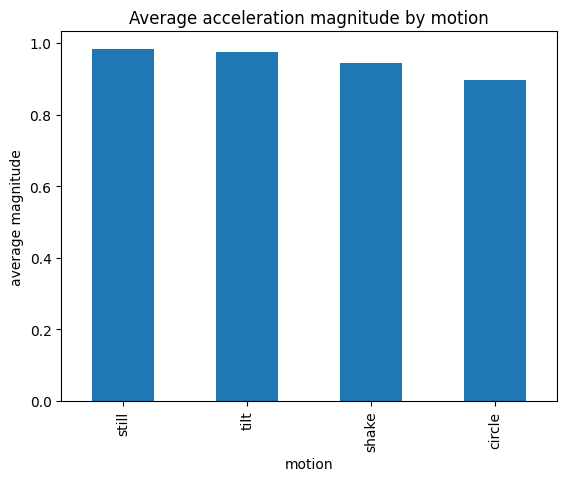

In [7]:
import matplotlib.pyplot as plt

avg_mag = df.groupby("motion")["magnitude"].mean().sort_values(ascending=False)
avg_mag.plot(kind="bar")
plt.title("Average acceleration magnitude by motion")
plt.xlabel("motion")
plt.ylabel("average magnitude")
plt.show()


### B) Line plot over time (within one motion)
Pick one motion and plot magnitude across `t`.
This helps you see how the motion changes from moment to moment.


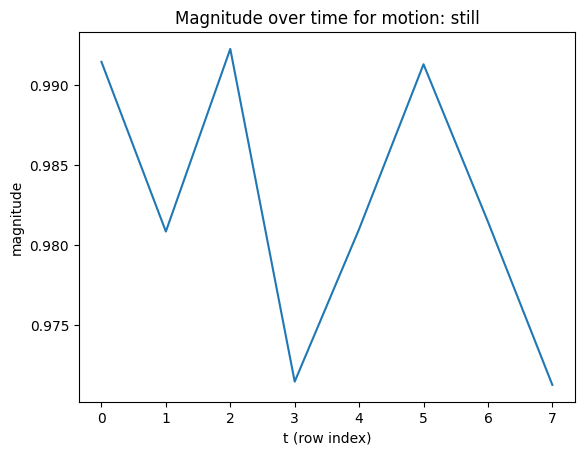

In [8]:
# Change this to one of your motion labels:
motion_to_plot = df["motion"].unique()[0] if len(df) else "still"

subset = df[df["motion"] == motion_to_plot].sort_values("t")
plt.figure()
plt.plot(subset["t"], subset["magnitude"])
plt.title(f"Magnitude over time for motion: {motion_to_plot}")
plt.xlabel("t (row index)")
plt.ylabel("magnitude")
plt.show()


### C) Compare distributions (optional)
A simple histogram can show if one motion tends to have larger values than another.


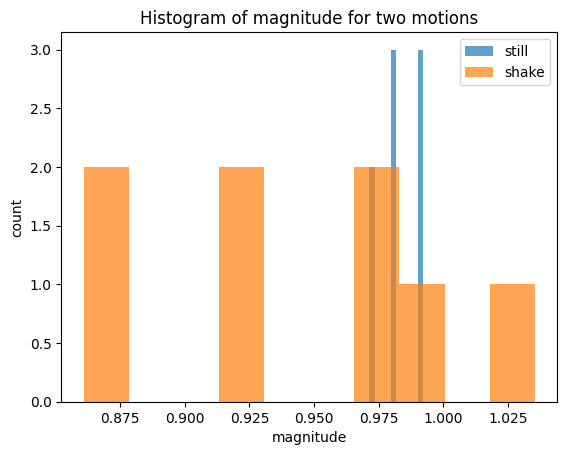

In [9]:
motions = df["motion"].unique().tolist()
if len(motions) >= 2:
    m1, m2 = motions[0], motions[1]
    plt.figure()
    plt.hist(df[df["motion"]==m1]["magnitude"], alpha=0.7, label=m1)
    plt.hist(df[df["motion"]==m2]["magnitude"], alpha=0.7, label=m2)
    plt.title("Histogram of magnitude for two motions")
    plt.xlabel("magnitude")
    plt.ylabel("count")
    plt.legend()
    plt.show()
else:
    print("Add at least two motion categories to compare histograms.")


## Part 7 — Connect Back to the Magic Wand Example
The Magic Wand recognizes gestures because different gestures create different **patterns** in sensor readings.

Use your results to answer:
- Which motion/gesture had the **largest average magnitude**?
- Which axis (`ax`, `ay`, `az`) seemed most important for your gesture?
- Did your plot over time show a recognizable pattern?

📸 **Picture to add (recommended):** a screenshot showing a detected gesture in the Serial Monitor.


## Part 8 — Export Your Dataset (Optional but useful)
If you want to save your dataset as a file (CSV), run the cell below.


In [ ]:
csv_path = "pbl2_arduino_motion_data.csv"
df.to_csv(csv_path, index=False)
csv_path


## 🧠 Final Reflection (short answers)
Write 4–8 sentences total.

1) In your table, what does each **row** represent? What does each **column** represent?

2) In Data 8, we compare categories (like flavors) using averages. In this lab, what are the **categories** and what are the **numerical variables**?

3) What did your visualizations show about differences between motions/gestures?

4) If you were designing an AI gesture recognizer, what feature(s) might you use (e.g., magnitude, ax, ay, az, etc.) and why?
